In [68]:
from methylseqnet import dna_io, inference, metrics, peaks
import methylseqnet
from dimelo import load_processed, plot_enrichment_profile
from matplotlib import pyplot as plt
import torch
import numpy as np
from Bio import motifs, Seq
import pysam
from tqdm.auto import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, auc, f1_score
from matplotlib.ticker import MultipleLocator

In [2]:
ref_genome = '/clusterfs/nilah/oberon/jupyter/chm13.draft_v1.0.fasta'
CpG_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/cpg_bam_whole_genome/pileup.sorted.bed.gz'
mA_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/allcontext_bam_whole_genome/pileup.sorted.bed.gz'

In [41]:
with open('/clusterfs/nilah/oberon/datasets/motifs/MA0139.1_forward.pfm','r') as f:
    forward_pfm = motifs.read(f,'pfm',strict=False)
with open('/clusterfs/nilah/oberon/datasets/motifs/MA0139.1_reverse.pfm','r') as f:
    reverse_pfm = motifs.read(f,'pfm')
forward_pwm = forward_pfm.counts.normalize(pseudocounts=0.1).log_odds()
reverse_pwm = reverse_pfm.counts.normalize(pseudocounts=0.1).log_odds()

In [5]:
print(max(max_by_bin))
print(len(max_by_bin))

25
482088


In [37]:
# print(sorted_matches[0])
# print(sorted_matches_rc[-1])

(61703850, 2.6621757)
(-61703869, 2.6621757)


482088


In [32]:
print(metrics.all_metrics(chr19_peaks,max_by_bin/12))

{'accuracy': 0.9100703605980651, 'precision': 0.04124122129800269, 'recall': 0.2542997542997543, 'f1': 0.07097244246346376, 'prc_auc': 0.07956712578381825}


In [30]:
pileup_hp1_nmp = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/chrX_hp1_processed/pileup.sorted.bed.gz'
pileup_hp2_nmp = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/chrX_hp2_processed/pileup.sorted.bed.gz'
pileup_hp1 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_cpg/pileup.sorted.bed.gz'
pileup_hp2 = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_cpg/pileup.sorted.bed.gz'
pileup_hp1_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp1_ma/pileup.sorted.bed.gz'
pileup_hp2_allcontext = '/clusterfs/nilah/oberon/datasets/deep_ctcf/phased/megalodon/hp2_ma/pileup.sorted.bed.gz'

In [31]:
model_paths = [
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-12-34_in4',
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-13-35_in5',
    '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/models/bd417dd_2024-05-20_14-33-39_in1',
]

In [32]:
models = [inference.load_for_eval(model_path) for model_path in model_paths]

In [39]:
chromosome = 'chrX'
# start = 130_064_000 - 20_000
# end = 130_080_000 + 20_000
start = 130_080_000
end = 130_100_000
# start = 37_728_599
# end = 37_733_817

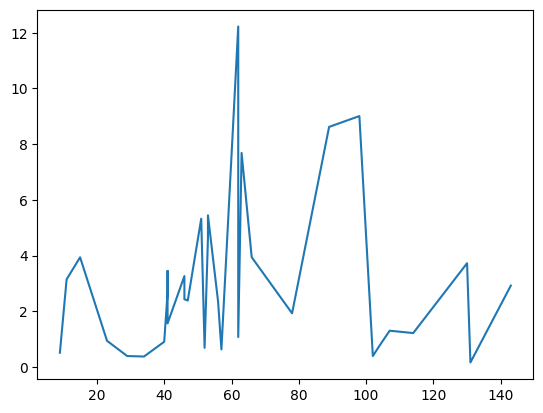

In [42]:
ref_fasta = pysam.FastaFile(ref_genome)
matches = list(forward_pwm.search(Seq.Seq(ref_fasta.fetch(chromosome,start,end))))
match_positions = []
match_values = []
for match in matches:
    if match[0]>0:
        match_positions.append(match[0]//128)
        match_values.append(match[1])
plt.plot(match_positions,match_values)

In [43]:
onehot_inputs = []
onehot_hp1 = []
onehot_hp2 = []
for chunk_start in range(start,end,128):
    onehot_inputs.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=CpG_pileup,
        )
    )
    onehot_hp1.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp1,
        )
    )
    onehot_hp2.append(
        dna_io.one_hot_dna_from_file(
            chromosome=chromosome,
            start=chunk_start,
            end=chunk_start + 896,
            ref_genome=ref_genome,
            cpg=True,
            cpg_bedmethyl=pileup_hp2,
        )
    )

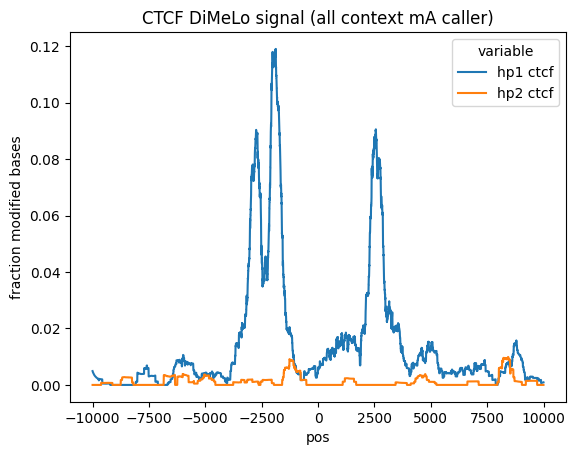

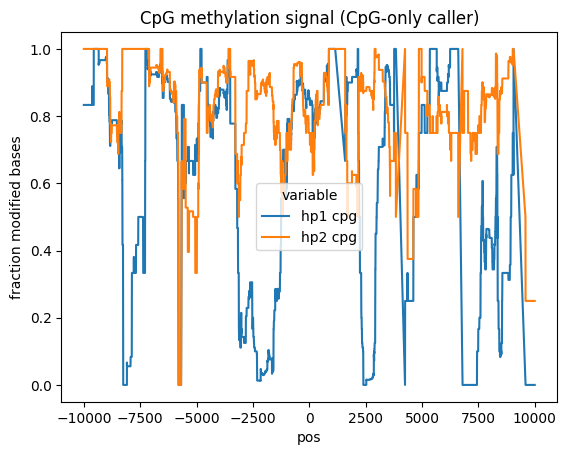

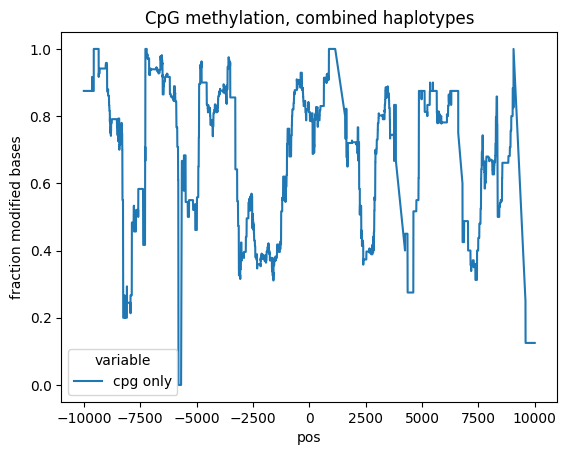

In [50]:
region = f'{chromosome}:{start}-{end}'
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [pileup_hp1_allcontext,pileup_hp2_allcontext],#CpG_pileup,pileup_hp1,pileup_hp2,pileup_hp1_nmp,pileup_hp2_nmp],
    regions_list = [region,region],#region,region,region,region,region],
    sample_names = ['hp1 ctcf','hp2 ctcf'],#'cpg only','hp1 cpg','hp2 cpg','hp1 guppy','hp2 guppy'],
    motifs = ['A,0','A,0'],#'CG,0','CG,0','CG,0','CG,0','CG,0'],
    window_size = None,
    smooth_window = 500,
)
plt.title('CTCF DiMeLo signal (all context mA caller)')
plt.show()
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [pileup_hp1,pileup_hp2],#pileup_hp1_nmp,pileup_hp2_nmp],
    regions_list = [region,region],#region,region],
    sample_names = ['hp1 cpg','hp2 cpg'],#'hp1 guppy','hp2 guppy'],
    motifs = ['CG,0','CG,0'],#'CG,0','CG,0'],
    window_size = None,
    smooth_window = 500,
)
plt.title('CpG methylation signal (CpG-only caller)')
plt.show()
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [CpG_pileup],#pileup_hp1,pileup_hp2],#pileup_hp1_nmp,pileup_hp2_nmp],
    regions_list = [region],#region,region],#region,region],
    sample_names = ['cpg only'],#'hp1 cpg','hp2 cpg'],#'hp1 guppy','hp2 guppy'],
    motifs = ['CG,0'],#'CG,0','CG,0'],#'CG,0','CG,0'],
    window_size = None,
    smooth_window = 500,
)
plt.title('CpG methylation, combined haplotypes')
plt.show()
# samtools view -N qnames_list.txt -o filtered_output.bam input.bam, requires samtools 1.12 or greater

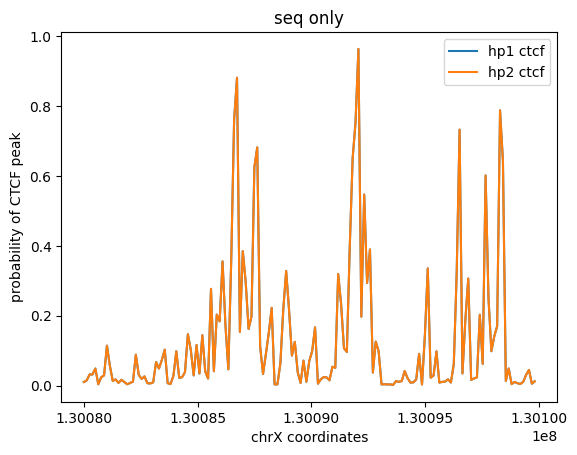

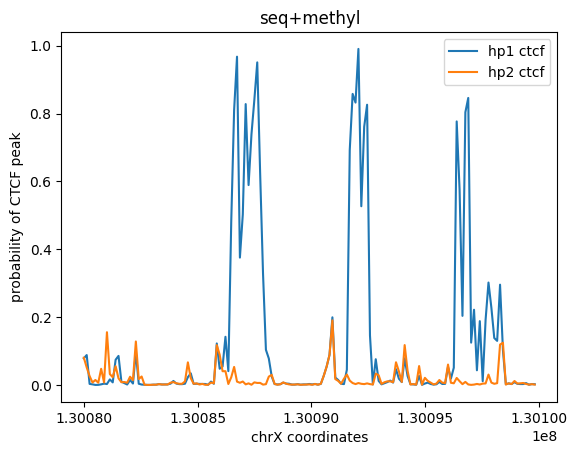

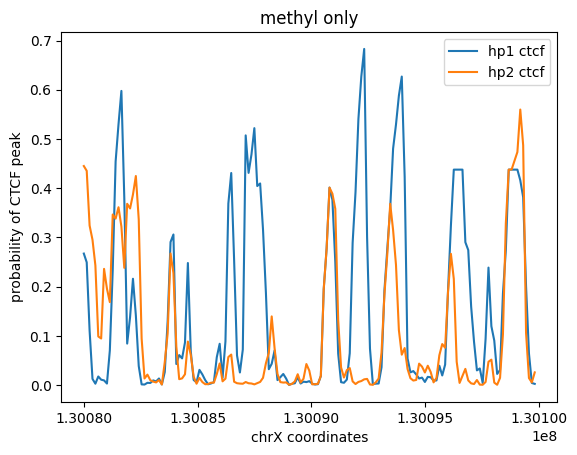

In [69]:
# print(np.array(onehot_hp2).shape)
# print(np.array(onehot_hp2).shape)
# onehot_hp2 = np.array(onehot_hp2)
# onehot_hp2[:,:,-1] = 0.7
for idx,model in enumerate(models):
    # for onehot in [onehot_inputs,onehot_hp1,onehot_hp2]:
    name = model_paths[idx][-1]
    if name=='4':
        mod_name = 'seq only'
    elif name=='5':
        mod_name = 'seq+methyl'
    elif name=='1':
        mod_name = 'methyl only'
    else:
        mod_name = name
    predictions_hp1 = torch.sigmoid(model(torch.tensor(np.transpose(np.array(onehot_hp1), (0,2,1)),dtype=torch.float32)).detach())
    predictions_hp2 = torch.sigmoid(model(torch.tensor(np.transpose(np.array(onehot_hp2), (0,2,1)),dtype=torch.float32)).detach())
    x_values = range(start,end-128,(end-start)//len(predictions_hp1))
    fig, ax = plt.subplots()
    ax.plot(x_values,np.array(predictions_hp1),label='hp1 ctcf')
    ax.plot(x_values,np.array(predictions_hp2),label='hp2 ctcf')
    ax.set_title(mod_name)
    ax.set_xlabel('chrX coordinates')
    ax.set_ylabel('probability of CTCF peak')
    ax.legend()
    ax.xaxis.set_major_locator(MultipleLocator(5000))
    # # plt.plot(match_positions,match_values)
    plt.show()

In [3]:
model_results_dict = {}

In [4]:
matches, contig_length = methylseqnet.motifs.find_motifs(
    genome_fasta=ref_genome,
    motif_pfm='/clusterfs/nilah/oberon/datasets/motifs/MA0139.1_forward.pfm',
    chromosome='chr19',
    start=0,
    end=1000000000,
)
max_by_bin = methylseqnet.motifs.bin_and_max(
    matches=matches,
    bin_size=128,
    contig_length=contig_length
)

In [5]:
mA_pileup = '/clusterfs/nilah/oberon/datasets/deep_ctcf/allcontext_bam_whole_genome/pileup.sorted.bed.gz'
chr19_peaks = peaks.peaks_from_bedmethyl(
    bedmethyl_file=mA_pileup,
    fasta_file=ref_genome,
    chromosome='chr19',
    bin_size=128,
    threshold=0.05,
)
print(len(chr19_peaks))

482088


In [6]:
model_results_dict['canonical_motif'] = (chr19_peaks,max_by_bin/12)

In [3]:
# chrX_dataset = '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/chrX_ALL_th0.05_56cb7b6.h5'
# targets,probabilities = inference.run_whole_dataset(
#     model_paths[1],
#     chrX_dataset,
# )
# print(metrics.all_metrics(targets,probabilities))

In [6]:
# test_dataset = '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/test_th0.05_fd6d75e.h5'
# test_targets,test_probabilities = inference.run_whole_dataset(
#     model_paths[1],
#     test_dataset,
# )
# print(metrics.all_metrics(test_targets,test_probabilities))

In [11]:
chr19_dataset = '/clusterfs/nilah/oberon/datasets/methylseq-net_deep-ctcf/chr19_ALL_th0.05_56cb7b6.h5'
for model_path in model_paths:
    name = Path(model_path).stem[-1]+"_channel"
    print(name)
    model_results_dict[name] = inference.run_whole_dataset(
        model_path,
        chr19_dataset,
    )

4_channel


model passes:   0%|          | 0/471 [00:00<?, ?batch/s]

5_channel


model passes:   0%|          | 0/471 [00:00<?, ?batch/s]

1_channel


model passes:   0%|          | 0/471 [00:00<?, ?batch/s]

In [18]:
# Get the length of the existing array
length = len(chr19_peaks)

# Calculate the number of values that should be above 0.5
num_above_0_5 = int(0.005 * length)

# Generate values
values_above_0_5 = np.random.uniform(0.5, 1.0, num_above_0_5)
values_below_0_5 = np.random.uniform(0.0, 0.5, length - num_above_0_5)

# Combine and shuffle the array
random_array = np.concatenate((values_above_0_5, values_below_0_5))
np.random.shuffle(random_array)
print(random_array)

[0.13487035 0.24142805 0.09401393 ... 0.01743621 0.23051501 0.11390988]


In [19]:
model_results_dict['random'] = (chr19_peaks,random_array)

Text(0.5, 1.0, 'Precision-Recall Curve - Comparing Models')

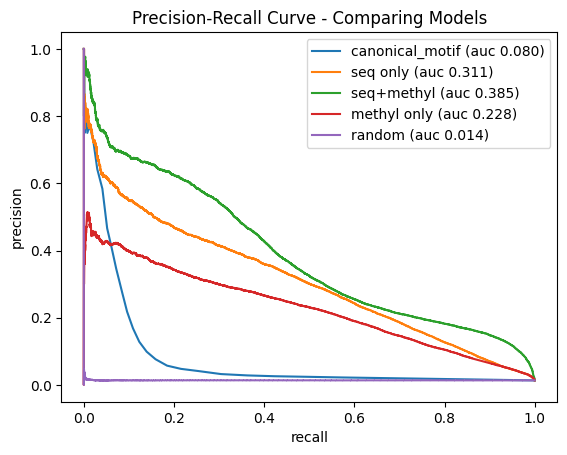

In [56]:
for name,(peaks,probabilities) in model_results_dict.items():
    precision, recall, thresholds = precision_recall_curve(peaks, probabilities)
    pr_auc = auc(recall, precision)
    if name=='4_channel':
        mod_name = 'seq only'
    elif name=='5_channel':
        mod_name = 'seq+methyl'
    elif name=='1_channel':
        mod_name = 'methyl only'
    else:
        mod_name = name
    label = mod_name+f" (auc {pr_auc:.3f})"
    plt.plot(recall,precision,label=label)
plt.legend()
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('Precision-Recall Curve - Comparing Models')